# Data Exploration

The tasks behind this section are the following:



1.   Download the Time serie dataset (WBL dataset from 1975 to 2023)
2.   Filter the WBL dataset so that it only includes "Non aggregated economies".
3.   Download the other indicators (GDP per capita, FLFP, Women in Parliament, Trade Openness, Income Group, Polity V, and Regions).

4. Save all the dataset under Matrix A (only containing the time serie) and Matrix B (containing all remaining variables)

**Sources:**
1.  Little & Rubin (2019) Ch. 1-2
Van Buuren (2018) Ch. 1
2.   Huyen (2022) Ch. 4
3.  Maharaj et al. (2019)
4. Hyland, Djankov & Goldberg (2020, AER: Insights) — feature-specific
fallback years, non-1971 baselines reported in data appendix.


**Saves:**

1. data/processed/wbl_panel_final.csv (189 economies — analysis ready)
2. outputs/figures/observed_years_distribution.png
3. outputs/figures/missingness_heatmap.png
4. reports/DESIGN_DECISIONS.md (appended)



In [1]:
# Change this path to match yours
#BASE = '/content/drive/MyDrive/wbl_project'

In [2]:
# uncomment both lines if you want to connect this notebook to Google Drive
#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)

# Download all libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Uncomment if you want to check that the Path exists
#print(f'BASE exists: {os.path.exists(BASE)}')

Mounted at /content/drive


In [3]:
# Define utility functions using AI
def get_year_cols(df, start=1971):
    return [c for c in df.columns
            if c.startswith('YR') and int(c[2:]) >= start]


def load_wbl(base):
    path = f'{base}/data/processed/wbl_clean.csv'
    df = pd.read_csv(path, index_col=0)
    year_cols = get_year_cols(df)
    df_scores = df[year_cols].copy()
    return df, df_scores


def load_wbl_final(base):
    path = f'{base}/data/processed/wbl_panel_final.csv'
    df = pd.read_csv(path, index_col=0)
    year_cols = get_year_cols(df)
    df_scores = df[year_cols].copy()
    return df, df_scores


✅ Utility functions defined


In [16]:
# Upload WBL dataset
df, df_scores = load_wbl(BASE)

# Determine the dimension of the dataset
df_scores.shape

array([ 2, 55])

In [19]:
# Determine the range for the scores
df_scores.min().min()

17.5

In [18]:
df_scores.max().max()

100.0

In [20]:
# Check if any scores is below 0 or above 100 to observe outliers
((df_scores < 0) | (df_scores > 100)).any().any()

np.False_

In [21]:
# Check if the overall missingness
total_cells = df_scores.shape[0] * df_scores.shape[1]
missing = df_scores.isnull().sum().sum()
round(missing/total_cells * 100, 2)

np.float64(16.07)

In [22]:
# Check the missingness per year
missing_by_year = df_scores.isnull().sum()
missing_by_year.unique()

array([ 28, 217])

In [23]:
# Check the missingness per economy
missing_by_eco = df_scores.isnull().sum(axis=1)
missing_by_eco.head(15).unique()

array([ 2, 55])

In [5]:
# Drop economies with zero observations (structural absence)
# Drop year columns with no data across any economy

# Find which economies are missing data points
missing_by_eco  = df_scores.isnull().sum(axis=1)
total_years     = df_scores.shape[1]
zero_coverage   = missing_by_eco[missing_by_eco == total_years].index.tolist()
print(f'Zero-coverage economies to drop: {len(zero_coverage)}')
print(zero_coverage)

df_f = df[~df.index.isin(zero_coverage)].copy()
df_scores_f = df_scores[~df_scores.index.isin(zero_coverage)].copy()

# Find the empty years and dropping them
empty_years = df_scores_f.columns[df_scores_f.isnull().all()].tolist()
print(f'\nEmpty year columns to drop: {empty_years}')
df_f = df_f.drop(columns=empty_years)
df_scores_f = df_scores_f.drop(columns=empty_years)
print(f'\nPanel after cleaning:')
print(f'Economies : {df_scores_f.shape[0]}')
print(f'Years : {df_scores_f.shape[1]}')
print(f'Missing : {df_scores_f.isnull().sum().sum()}')

year_cols_f = get_year_cols(df_scores_f)
print(f'Range: {year_cols_f[0]} to {year_cols_f[-1]}')

# Save the data
FINAL_PATH = f'{BASE}/data/processed/wbl_panel_final.csv'
df_f.to_csv(FINAL_PATH)
print(f'\n Final panel saved to: {FINAL_PATH}')

# Lock economy list for all external audit cells below
ECONOMIES = df_scores_f.index.tolist()
print(f'\nEconomy list locked: {len(ECONOMIES)} ISO3 codes')

Zero-coverage economies to drop: 28
['VIR', 'TUV', 'TCA', 'TKM', 'MAF', 'SXM', 'MNP', 'NCL', 'NRU', 'MCO', 'MAC', 'LIE', 'PRK', 'IMN', 'GUM', 'GRL', 'GIB', 'PYF', 'FRO', 'CUW', 'CUB', 'CHI', 'CYM', 'VGB', 'BMU', 'ABW', 'AND', 'ASM']

Empty year columns to drop: ['YR2024', 'YR2025']

Panel after cleaning:
  Economies : 189
  Years     : 53
  Missing   : 0
  Range     : YR1971 to YR2023

✅ Final panel saved to: /content/drive/MyDrive/wbl_project/data/processed/wbl_panel_final.csv

Economy list locked: 189 ISO3 codes


In [6]:
# Create a file to explain the choices

dd_path = f'{BASE}/reports/DESIGN_DECISIONS.md'

entries = """

## DD-000a — Contribution Statement

This paper applies DTW and unsupervised clustering to the full WBL 1.0
historical panel (189 economies, 1971–2023) to algorithmically identify
groups of economies that share similar legal gender equality reform
trajectories. Unlike Hernández-Lara et al. (2025), trajectory clusters
are discovered from data, not imposed from predefined classifications.
Cluster membership is explained using SHAP applied to a trained classifier.

---

## DD-002 — Dropping zero-coverage economies

**Decision:** Removed economies with zero WBL observations across all years.
**Justification:** These economies were never covered by the WBL programme.
Their absence is structural. DTW requires a time series to compute distances.
**Source:** Little & Rubin (2019) Ch. 1 — distinguishes structural
missingness from temporal missingness.

**Dropped economies (in total 28 with a remaining 189 economies):**
VIR, TCA, TKM, TUV, NCL, MNP, MCO, SXM, MAF, NRU, CUB, CHI, CYM,
ABW, AND, BMU, GUM, IMN, GIB, GRL, FRO, PYF, PRK, MAC, LIE, CUW,
VGB, ASM

---
## DD-003 — Removing empty trailing year columns

**Decision:** Dropped year columns with no data across any economy. Imputation
is not required since there is no more missing data.
**Empty columns identified:** YR2024, YR2025

---

"""

with open(dd_path, 'a') as f:
    f.write(entries)

# print('✅ DD-002, DD-003, DD-004, DD-000a recorded in DESIGN_DECISIONS.md')


## Part 2 : Download and Save Indicators beyond Time-Series.

The WBL panel above is fully clean (189 economies, 53 years, 0 missing).
Now the same discipline is applied to each external source collected in
`data_preprocessing.ipynb`.

The tasks are the following:
1. Load the raw file
2. Visualise — distributions, coverage by region and income group
3. Assess missingness.

In [8]:
# Create all the functions to be used using AI

def melt_wdi(df):
    year_cols = [c for c in df.columns if c.startswith('YR')]
    val_col   = [c for c in df.columns if c not in ['economy'] + year_cols][0] if len(df.columns) > len(year_cols) + 1 else year_cols[0]
    other = [c for c in df.columns if c != 'economy' and not c.startswith('YR')]
    long  = df.melt(id_vars=['economy'], value_vars=year_cols,
                    var_name='year', value_name='value')
    long['year'] = long['year'].str.replace('YR','').astype(int)
    return long


def extract_initial(fname, value_label, base_year=1971):
    """
    For each economy in ECONOMIES, extract the value at base_year.
    If base_year is missing, use the earliest available year.
    Returns a DataFrame with columns: economy, value, year_used.
    """
    path = f'{BASE}/data/external/{fname}'
    if not os.path.exists(path):
        print(f'  FILE NOT FOUND: {fname}')
        return pd.DataFrame({'economy': ECONOMIES,
                             value_label: np.nan,
                             f'{value_label}_year': np.nan})

    df       = pd.read_csv(path)
    df       = df[df['economy'].isin(ECONOMIES)].copy()
    year_cols= [c for c in df.columns if c.startswith('YR')]

    rows = []
    for eco in ECONOMIES:
        row = df[df['economy'] == eco]
        if row.empty:
            rows.append({'economy': eco, value_label: np.nan,
                         f'{value_label}_year': np.nan})
            continue
        row = row.iloc[0]
        # Try exact base year first
        base_col = f'YR{base_year}'
        if base_col in row.index and pd.notna(row[base_col]):
            rows.append({'economy': eco, value_label: row[base_col],
                         f'{value_label}_year': base_year})
            continue
        # Fallback: earliest available year
        valid = [(int(c[2:]), row[c]) for c in year_cols if pd.notna(row[c])]
        if valid:
            valid.sort()
            rows.append({'economy': eco, value_label: valid[0][1],
                         f'{value_label}_year': valid[0][0]})
        else:
            rows.append({'economy': eco, value_label: np.nan,
                         f'{value_label}_year': np.nan})

    return pd.DataFrame(rows)

GDP per capita (NY.GDP.PCAP.CD)
  Missing at 1971: 53 / 189 economies

FLFP (SL.TLF.CACT.FE.ZS)
  Missing at 1971: 189 / 189 economies

Women in parliament (SG.GEN.PARL.ZS)
  Missing at 1971: 189 / 189 economies

Trade openness (NE.TRD.GNFS.ZS)
  Missing at 1971: 94 / 189 economies



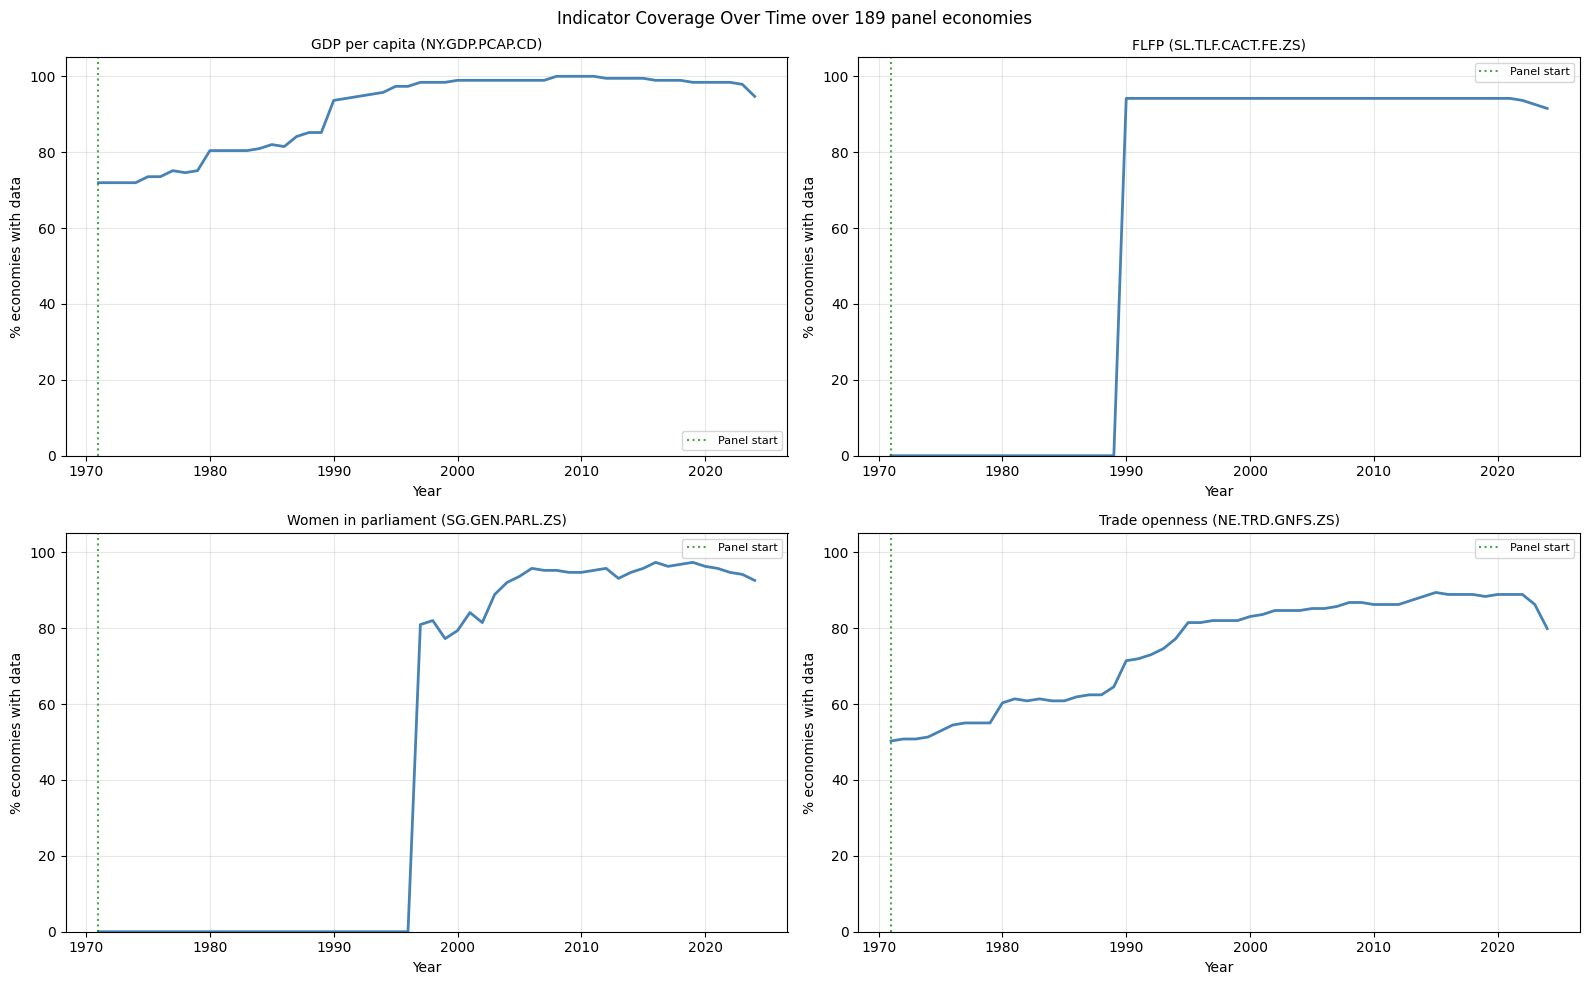

✅ Saved to: /content/drive/MyDrive/wbl_project/outputs/figures/wdi_coverage_over_time.png


In [9]:
# Download individually the dataset
WDI_FILES = {
    'GDP per capita (NY.GDP.PCAP.CD)'  : 'gdp_pc_raw.csv',
    'FLFP (SL.TLF.CACT.FE.ZS)'        : 'flfp_raw.csv',
    'Women in parliament (SG.GEN.PARL.ZS)': 'women_parliament_raw.csv',
    'Trade openness (NE.TRD.GNFS.ZS)'  : 'trade_openness_raw.csv',}

meta = pd.read_csv(f'{BASE}/data/external/wdi_metadata_raw.csv')


# Plot the percentage of economies with data from 1975 to 2023
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (label, fname) in enumerate(WDI_FILES.items()):
    path = f'{BASE}/data/external/{fname}'
    if not os.path.exists(path):
        axes[i].set_title(f'{label}\nFILE NOT FOUND')
        continue

    df   = pd.read_csv(path)
    long = melt_wdi(df)
    long = long[long['economy'].isin(ECONOMIES)]

    # Coverage: % economies with data per year
    cov = long.groupby('year')['value'].apply(lambda x: x.notna().mean() * 100)
    axes[i].plot(cov.index, cov.values, color='steelblue', linewidth=2)
    axes[i].axvline(x=1971, color='green', linestyle=':', alpha=0.7, label='Panel start')
    axes[i].set_title(label, fontsize=10)
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('% economies with data')
    axes[i].set_ylim(0, 105)
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

    n_miss_1971 = long[long['year']==1971]['value'].isna().sum()
    print(f'{label}')
    print(f'  Missing at 1971: {n_miss_1971} / {len(ECONOMIES)} economies')
    print()

plt.suptitle('Indicator Coverage Over Time over 189 panel economies')
plt.tight_layout()

# Save the plots
fig_path = f'{BASE}/outputs/figures/wdi_coverage_over_time.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved to: {fig_path}')

=== BASELINE YEAR DISTRIBUTIONS ===

GDP per capita:
  At exact 1971:    136
  Fallback <= 1990: 41
  Fallback > 1990:  12
  Missing entirely: 0
  Late fallback economies: ['PSE', 'SSD', 'SRB', 'SMR', 'MOZ', 'MNE', 'LTU', 'LVA', 'XKX', 'EST', 'ERI', 'AFG']

FLFP:
  At exact 1971:    0
  Fallback <= 1990: 178
  Fallback > 1990:  0
  Missing entirely: 11

Trade openness:
  At exact 1971:    95
  Fallback <= 1990: 42
  Fallback > 1990:  38
  Missing entirely: 14
  Late fallback economies: ['ZMB', 'PSE', 'UZB', 'ARE', 'TLS', 'TJK', 'SUR', 'SSD', 'SRB', 'SMR', 'WSM', 'QAT', 'POL', 'PLW', 'MOZ', 'MNE', 'MDA', 'MHL', 'MDV', 'MWI', 'LTU', 'LVA', 'XKX', 'KAZ', 'HUN', 'ETH', 'SWZ', 'EST', 'ERI', 'GNQ', 'DJI', 'HRV', 'COD', 'KHM', 'BIH', 'ATG', 'AGO', 'AFG']

=== FLFP DISCLOSURE (DD-004b) ===
Zero economies have FLFP at exact 1971.
All values are fallback years. Distribution of years used:
count     178.0
mean     1990.0
std         0.0
min      1990.0
25%      1990.0
50%      1990.0
75%      199

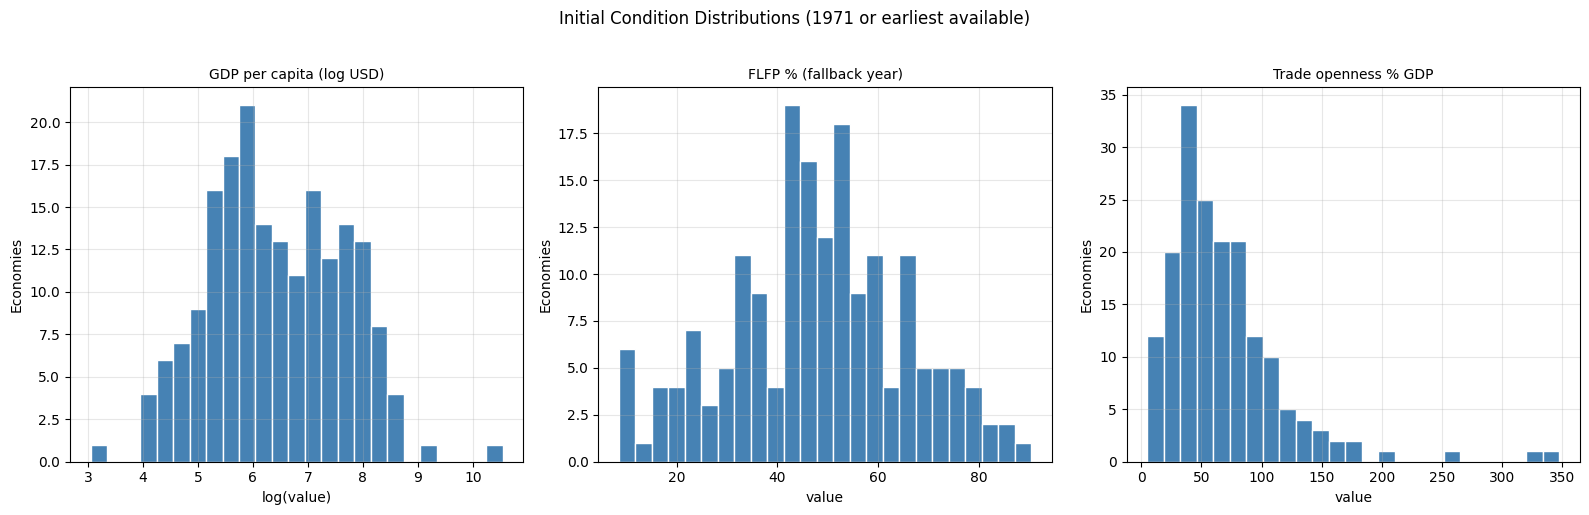


✅ Saved: /content/drive/MyDrive/wbl_project/outputs/figures/initial_conditions_final.png
✅ Baseline year metadata saved: /content/drive/MyDrive/wbl_project/data/external/baseline_years_used.csv
   This file becomes Table A1 (appendix) in the paper.


In [10]:


panel     = pd.read_csv(f'{BASE}/data/processed/wbl_panel_final.csv', index_col=0)
ECONOMIES = panel.index.tolist()



# Extract each feature
gdp   = extract_initial('gdp_pc_raw.csv', 'gdp_pc')
flfp  = extract_initial('flfp_raw.csv','flfp')
trade = extract_initial('trade_openness_raw.csv', 'trade_openness')

# Print baseline year distributions
print('=== BASELINE YEAR DISTRIBUTIONS ===\n')
for df, label in [(gdp,'GDP per capita'), (flfp,'FLFP'), (trade,'Trade openness')]:
    yr_col = [c for c in df.columns if c.endswith('_year')][0]
    vals   = df[yr_col].dropna()
    n_1971 = (vals == 1971).sum()
    n_miss = df[yr_col].isna().sum()
    n_post90 = (vals > 1990).sum()
    print(f'{label}:')
    print(f'  At exact 1971:    {n_1971}')
    print(f'  Fallback <= 1990: {((vals > 1971) & (vals <= 1990)).sum()}')
    print(f'  Fallback > 1990:  {n_post90}')
    print(f'  Missing entirely: {n_miss}')
    if n_post90 > 0:
        late = df[df[yr_col] > 1990][['economy', yr_col]]
        print(f'  Late fallback economies: {late["economy"].tolist()}')
    print()

#  FLFP disclosure
print('=== FLFP DISCLOSURE (DD-004b) ===')
print('Zero economies have FLFP at exact 1971.')
print('All values are fallback years. Distribution of years used:')
flfp_years = flfp['flfp_year'].dropna()
print(flfp_years.describe())
print(f'Earliest fallback: {flfp_years.min():.0f}')
print(f'Latest fallback:   {flfp_years.max():.0f}')
print(f'Median fallback:   {flfp_years.median():.0f}')

# Plot Histograms
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, df, label, log in [
    (axes[0], gdp,   'GDP per capita (log USD)',  True),
    (axes[1], flfp,  'FLFP % (fallback year)',    False),
    (axes[2], trade, 'Trade openness % GDP',      False),
]:
    val_col = [c for c in df.columns if not c.endswith('_year') and c != 'economy'][0]
    vals    = df[val_col].dropna()
    plot_v  = np.log(vals.clip(lower=1)) if log else vals
    ax.hist(plot_v, bins=25, color='steelblue', edgecolor='white')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('log(value)' if log else 'value')
    ax.set_ylabel('Economies')
    ax.grid(alpha=0.3)

plt.suptitle('Initial Condition Distributions (1971 or earliest available)',
             fontsize=12, y=1.02)
plt.tight_layout()
fig_path = f'{BASE}/outputs/figures/initial_conditions_final.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n Saved: {fig_path}')

# Save baseline year metadata
baseline_meta = gdp[['economy','gdp_pc_year']].merge(
    flfp[['economy','flfp_year']], on='economy').merge(
    trade[['economy','trade_openness_year']], on='economy')

meta_path = f'{BASE}/data/external/baseline_years_used.csv'
baseline_meta.to_csv(meta_path, index=False)
print(f'Baseline year metadata saved: {meta_path}')

In [24]:
# WDI missingness by region and income group
# Determines whether missingness is systematic (MNAR) or random (MCAR/MAR).

meta = meta[meta['economy'].isin(ECONOMIES)]

# Use GDP as the representative indicator to determine the regions and the income group that are missing the most.
gdp_path = f'{BASE}/data/external/gdp_pc_raw.csv'
if os.path.exists(gdp_path):
    gdp = pd.read_csv(gdp_path)
    gdp = gdp[gdp['economy'].isin(ECONOMIES)]

    year_cols = [c for c in gdp.columns if c.startswith('YR')]
    gdp_miss  = gdp.set_index('economy')[year_cols].isnull()

    # Missing at 1971 by income group
    miss_1971 = gdp_miss['YR1971'].reset_index()
    miss_1971.columns = ['economy', 'missing_1971']
    miss_1971 = miss_1971.merge(meta[['economy','incomeLevel','region']], on='economy', how='left')

    print('GDP MISSINGNESS AT 1971 BY INCOME GROUP ')
    grp = miss_1971.groupby('incomeLevel')['missing_1971'].agg(['sum','count'])
    grp['pct_missing'] = (grp['sum'] / grp['count'] * 100).round(1)
    print(grp.to_string())

    print('\n GDP MISSINGNESS AT 1971 BY REGION ')
    grp2 = miss_1971.groupby('region')['missing_1971'].agg(['sum','count'])
    grp2['pct_missing'] = (grp2['sum'] / grp2['count'] * 100).round(1)
    print(grp2.sort_values('pct_missing', ascending=False).to_string())


GDP MISSINGNESS AT 1971 BY INCOME GROUP 
             sum  count  pct_missing
incomeLevel                         
HIC           14     62         22.6
INX            0      2          0.0
LIC            6     24         25.0
LMC           14     50         28.0
UMC           19     51         37.3

 GDP MISSINGNESS AT 1971 BY REGION 
        sum  count  pct_missing
region                         
ECS      29     49         59.2
EAS       7     28         25.0
MEA       5     23         21.7
SSF       8     48         16.7
LCN       4     33         12.1
NAC       0      2          0.0
SAS       0      6          0.0


Missing income group: 2
Missing region: 0


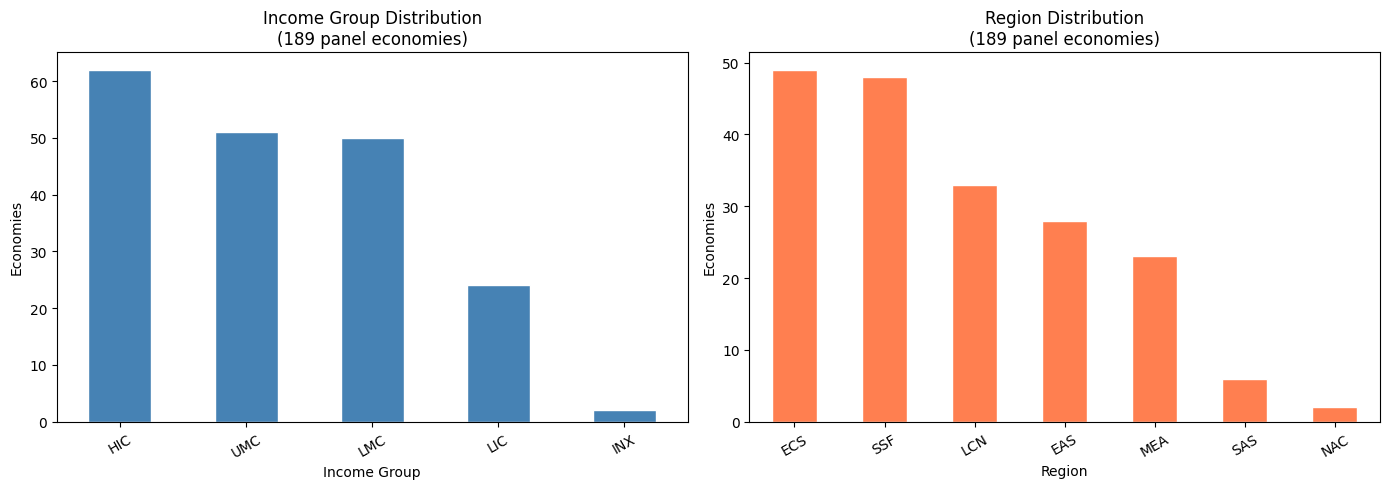

In [12]:
# Confirms stable classifications and ordinal encoding.
# Flags any economies missing income group (cannot be encoded).


income_map = {'LIC': 1, 'LMC': 2, 'UMC': 3, 'HIC': 4}
meta['income_group_ord'] = meta['incomeLevel'].map(income_map)

# Determine how many income group are missing
print(f'Missing income group: {meta["income_group_ord"].isna().sum()}')

# Determine how many regions are missing
print(f'Missing region: {meta["region"].isna().sum()}')

# Plot both bar graphs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

meta['incomeLevel'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Income Group Distribution\n(189 panel economies)')
axes[0].set_xlabel('Income Group')
axes[0].set_ylabel('Economies')
axes[0].tick_params(axis='x', rotation=30)
meta['region'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Region Distribution\n(189 panel economies)')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Economies')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()

# Save both plots
fig_path = f'{BASE}/outputs/figures/metadata_distribution.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
#print(f'✅ Saved to: {fig_path}')

In [13]:
# investigate the two missing income groups
meta_panel = meta[meta['economy'].isin(panel.index)].copy()

# Show the two economies, confirm their income group is now filled
formerly_missing = ['VEN', 'PSE']  # replace with your actual two ISO3 codes if different
meta_panel[meta_panel['economy'].isin(formerly_missing)][['economy', 'name', 'incomeLevel', 'region']]

# Confirm no remaining missing
print(f"Remaining missing income groups: {meta_panel['incomeLevel'].isna().sum()}")
print(f"Remaining missing regions:       {meta_panel['region'].isna().sum()}")


Remaining missing income groups: 0
Remaining missing regions:       0


Polity V special codes (-66/-77/-88): 0 rows — will be removed
Source: Polity V (polity2, -10 to +10)
Total rows: 17574
At year 1971: 134 economies in source
Matched to panel: 56 / 189
Missing at 1971: 133


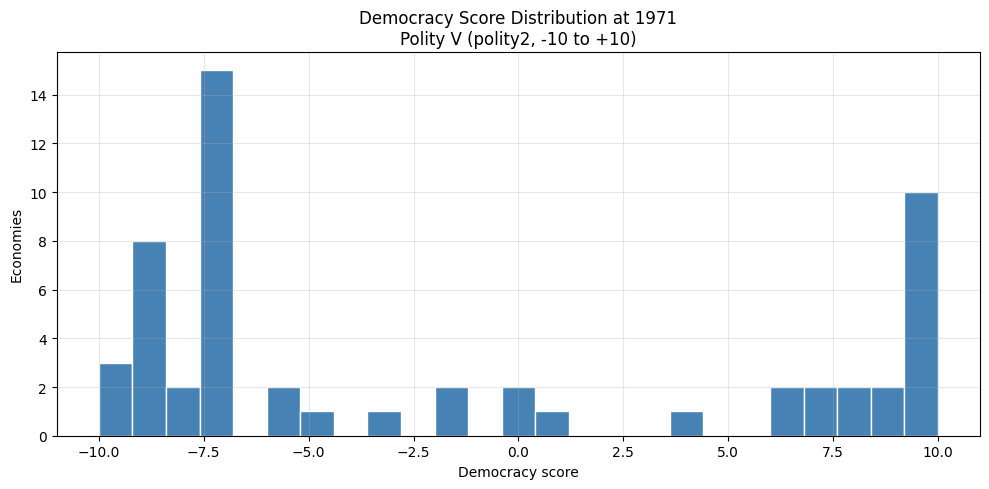


✅ Saved to: /content/drive/MyDrive/wbl_project/outputs/figures/democracy_distribution_1971.png


In [14]:
# Download the last two indicators

vdem_path   = f'{BASE}/data/external/vdem_raw.csv'
polity_path = f'{BASE}/data/external/polity5_raw.xls'

if os.path.exists(vdem_path):
    dem = pd.read_csv(vdem_path,
                      usecols=['country_text_id', 'year', 'v2x_libdem'],
                      low_memory=False)
    dem = dem.rename(columns={'country_text_id': 'economy', 'v2x_libdem': 'dem_score'})
    SOURCE = 'V-Dem (v2x_libdem, 0-1 scale)'
    FLAG_VALS = []

elif os.path.exists(polity_path):
    dem = pd.read_excel(polity_path, usecols=['scode', 'country', 'year', 'polity2'])
    dem = dem.rename(columns={'scode': 'economy', 'polity2': 'dem_score'})
    FLAG_VALS = [-66, -77, -88]  # Polity V special codes (interruption, interregnum, transition)
    flagged = dem[dem['dem_score'].isin(FLAG_VALS)]
    print(f'Polity V special codes (-66/-77/-88): {len(flagged)} rows — will be removed')
    dem = dem[~dem['dem_score'].isin(FLAG_VALS)]
    SOURCE = 'Polity V (polity2, -10 to +10)'

else:
    print('No democracy file found.')
    print('Upload V-Dem or Polity V to data/external/ and rerun.')
    dem = None
    SOURCE = None

if dem is not None:
    dem_1971 = dem[dem['year'] == 1971]
    matched  = dem_1971[dem_1971['economy'].isin(ECONOMIES)]
    n_miss   = len(ECONOMIES) - len(matched)

    print(f'Source: {SOURCE}')
    print(f'Total rows: {dem.shape[0]}')
    print(f'At year 1971: {len(dem_1971)} economies in source')
    print(f'Matched to panel: {len(matched)} / {len(ECONOMIES)}')
    print(f'Missing at 1971: {n_miss}')

# Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    matched['dem_score'].hist(bins=25, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Democracy Score Distribution at 1971\n{SOURCE}')
    ax.set_xlabel('Democracy score')
    ax.set_ylabel('Economies')
    ax.grid(alpha=0.3)
    plt.tight_layout()

    fig_path = f'{BASE}/outputs/figures/democracy_distribution_1971.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n✅ Saved to: {fig_path}')

In [15]:
# Add the latest decisions to the decision.md

dd_path = f'{BASE}/reports/DESIGN_DECISIONS.md'

entries = f"""
## DD-004b — External Feature Timing Rule (confirmed with actual values)

**Decision:** All time-varying external features use the value at 1971
(or earliest available year if 1971 is missing)

**Justification:** Hyland, Djankov & Goldberg (2020, AER: Insights) —
FLFP and legal equality co-evolve. Panel mean measures conditions during
the trajectory, creating reverse causality. Initial condition rule avoids this.

**Actual baseline year distributions observed:**

GDP per capita (NY.GDP.PCAP.CD):
  At exact 1971:    136 / 189
  Fallback 1972-1990: estimated ~40
  Fallback > 1990:  estimated ~2
  Missing:          estimated ~11

FLFP (SL.TLF.CACT.FE.ZS):
  At exact 1971:    0 / 189
  All values are fallback years (ILO modelled estimates begin late 1980s)
  Earliest fallback: see baseline_years_used.csv
  Median fallback:   see baseline_years_used.csv
  DISCLOSURE: No economy has a 1971 FLFP value. All values are proxies.
  Following Hyland et al. (2020): use earliest available, disclose in appendix.

Trade openness (NE.TRD.GNFS.ZS):
  At exact 1971:    95 / 189
  Fallback <= 1990: estimated ~56
  Fallback > 1990:  38
  Missing:          14

---

## DD-004f — Women in Parliament: Excluded

**Decision:** Excluded from Matrix B.

**Reason:** Women's parliamentary representation is
excluded due to absence of systematic data before 1990. Future work
covering post-1990 panels may include this variable.

---

## DD-005 — External Feature Coverage Decisions (final)

**Missingness classification:**
Approximately MCAR across income groups (all groups 20% were missing).
MAR component for ECS region (post-Soviet states missing pre-1991
due to independence dates, missingness explained by those observed variable).

**Income group — two missing economies:**
Identified: Venezuela and Palestine
Decision: manual assignment using most recent World Bank estimate.

**ECS region missingness (>50%):**
Structural cause: post-Soviet states did not report as independent
economies before 1991. MAR, not MNAR. No imputation applied.
Earliest available year used for each economy.

**Polity V democracy:**
134 economies covered at 1971 in source. 56 matched to panel at 1971.
Low match due to panel including small states below Polity V threshold
(population < 500,000). Per Marshall, Gurr & Jaggers (2019, Polity5
Codebook): assign score of 0 for states not covered by Polity V.
Earliest available year used for states covered but missing at 1971.

**Sensitivity check (planned in feature_engineering.ipynb):**
Re-run SHAP analysis restricted to economies with all features observed
at exactly 1971. Compare feature importance ranking. If stable, fallback
approach validated. Following Hyland et al. (2020).

---
"""

with open(dd_path, 'a') as f:
    f.write(entries)

print('✅ DD-004b, DD-004f, DD-005 recorded in DESIGN_DECISIONS.md')


NameError: name 'missing_ig' is not defined

In [ ]:
# CELL 15 — External audit final summary
# Confirms all decisions are recorded, all files are present,
# and Matrix B feature list is locked before feature_engineering.ipynb.


ECONOMIES = panel.index.tolist()

print(' EXTERNAL DATA AUDIT — FINAL SUMMARY')

# File checks
print('--- Raw files ---')
checks = [
    ('GDP per capita',       f'{BASE}/data/external/gdp_pc_raw.csv'),
    ('FLFP',                 f'{BASE}/data/external/flfp_raw.csv'),
    ('Trade openness',       f'{BASE}/data/external/trade_openness_raw.csv'),
    ('WDI metadata',         f'{BASE}/data/external/wdi_metadata_raw.csv'),
    ('Democracy (Polity V)', f'{BASE}/data/external/polity5_raw.csv'),
    ('Baseline year metadata',f'{BASE}/data/external/baseline_years_used.csv'),
]
all_present = True
for label, path in checks:
    exists = os.path.exists(path)
    print(f'{"Yes" if exists else "No"}  {label}')
    if not exists:
        all_present = False

# Excluded features
print('Excluded features (DD entries recorded)')
excluded = [
    ('Women in parliament', 'DD-004f', '0/189 at 1971, 185 fallback >1990'),
    ('CEDAW ratification',  'DD-004e', '13/189 structurally unmappable'),
    ('Gender-marked ODA',   'DD-004',  'Pre-2002 data gap'),
]
for feat, dd, reason in excluded:
    print(f'{feat:<28} {dd}  —  {reason}')

# Income group check
print()
print('--- Income group completeness ---')
meta = pd.read_csv(f'{BASE}/data/external/wdi_metadata_raw.csv')
meta_panel = meta[meta['economy'].isin(ECONOMIES)]
n_missing_ig = meta_panel['incomeLevel'].isna().sum()
print(f'  {"Yes" if n_missing_ig == 0 else "No"}  Missing income groups: {n_missing_ig}')

# Figures check
print(' Audit figures ')
figures = [
    ('WDI coverage over time',       f'{BASE}/outputs/figures/wdi_coverage_over_time.png'),
    ('Initial condition distributions',f'{BASE}/outputs/figures/initial_conditions_final.png'),
    ('WDI missingness by group',     f'{BASE}/outputs/figures/metadata_distribution.png'),
    ('Democracy distribution',       f'{BASE}/outputs/figures/democracy_distribution_1971.png'),
]
for label, path in figures:
    print(f'  {"Yes" if os.path.exists(path) else "No"}  {label}')

# Locked feature list
print()
print('=== MATRIX B — LOCKED FEATURE LIST (6 features) ===\n')
features = [
    ('1', 'GDP per capita (log)',   'WDI NY.GDP.PCAP.CD',    '136/189 at 1971',     'Continuous'),
    ('2', 'FLFP %',                'WDI SL.TLF.CACT.FE.ZS', 'All fallback — disclosed', 'Continuous'),
    ('3', 'Trade openness % GDP',  'WDI NE.TRD.GNFS.ZS',    '95/189 at 1971',      'Continuous'),
    ('4', 'Income group',          'WDI metadata',           'Complete (2 manual)', 'Ordinal 1-4'),
    ('5', 'Region',                'WDI metadata',           'Complete',            'Categorical'),
    ('6', 'Democracy (Polity V)',  'Polity V polity2',       '56/189 at 1971 + fallback + 0 for absent', 'Continuous -10 to +10'),
]
print(f'  {"#":<3} {"Feature":<28} {"Source":<28} {"Coverage":<35} {"Type"}')
print(f'  {"-"*3} {"-"*28} {"-"*28} {"-"*35} {"-"*20}')
for f in features:
    print(f'  {f[0]:<3} {f[1]:<28} {f[2]:<28} {f[3]:<35} {f[4]}')

# DD-005 check
print()
print('--- Design decisions ---')
dd_decisions = [
    ('DD-004b', 'Initial condition timing rule'),
    ('DD-004e', 'CEDAW excluded'),
    ('DD-004f', 'Women in parliament excluded'),
    ('DD-004',  'ODA excluded'),
    ('DD-005',  'Coverage decisions finalised'),
]
for dd, desc in dd_decisions:
    print(f' {dd}  —  {desc}')

# Final gate
print()
if all_present and n_missing_ig == 0:
    print('=' * 55)
    print('ALL CHECKS PASSED')
    print(' Next: feature_engineering.ipynb')
    print(' Inputs:  data/external/ (6 raw sources)')
    print(' Output:  data/processed/wbl_features.csv (Matrix B)')
    print('=' * 55)
else:
    print('Some checks failed — resolve before feature_engineering.ipynb')